# High Water — Predicting Venice Acqua Alta
Author: Tommaso Canalicchio |Date: May 2023

**Overview**
This notebook implements a full machine learning pipeline to predict high tide events
(acqua alta) in Venice 6 hours in advance, using meteorological data from stations
across the Venetian lagoon.

## Workflow summary

**Data loading & cleaning** — drop the high-missingness solar radiation column,
impute remaining missing values with KNN Imputer (k=10).

**Exploratory analysis** — correlation heatmap, class imbalance assessment,
collinearity inspection.


**Model selection & Hyperparameter search** (Randomized Search CV) — three models are explored, 
the Random Forest, the Gradient Boosting and the Adaboost calssifier. The last 
one is eventually chosen for the best prediction results. The parameter space for the
AdaBoost classifier (number of estimators, learning rate, base tree max depth) is
explored over 100 random combinations with 5-fold cross-validation. The scoring
function is a custom penalty metric that penalises false negatives (missed high
tides) five times more than false positives, reflecting the real-world cost of
failing to predict a flood event.

**Final model fitting** — once the best hyperparameter combination is identified
by the search, the AdaBoost model is re-fitted on the full training set using those
optimal values (n_estimators=87, learning_rate=1.219, max_depth=4).

**Test set prediction & export** — predictions are generated on the 866 test
observations for which no ground-truth labels are available locally. The
predicted values are exported and submitted to an external evaluation platform,
which computes and returns the score against the hidden true labels.

In [341]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import GradientBoostingClassifier
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV
from pprint import pprint
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, make_scorer


# Read data

In [570]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train_df = train_df.drop('Piattaforma_CNR_Solar_Radiation', axis=1)
test_df = test_df.drop('Piattaforma_CNR_Solar_Radiation', axis=1)
#train_df.dropna(inplace=True)


# Scaling

In [571]:
standard_scaler = StandardScaler()

standard_scaler.fit_transform(train_df)
standard_scaler.fit_transform(test_df)


array([[ 0.98546846, -1.09538005, -0.30782137, ...,  1.26972209,
        -0.22028952, -0.20069058],
       [-0.94991399,  0.50544889,  1.72815385, ..., -0.39406317,
        -0.22028952, -0.20069058],
       [-0.34818599, -1.12280325, -0.91024691, ..., -0.67296359,
        -0.22028952, -0.20069058],
       ...,
       [ 1.63294187,  0.32034233,  0.05474956, ..., -0.18248354,
        -0.22028952, -0.20069058],
       [-0.91472522,  0.29291914,  0.51214674, ..., -0.58640829,
        -0.22028952, -0.20069058],
       [ 1.5660832 , -0.85885501, -0.8684118 , ..., -0.92301224,
        -0.22028952, -0.20069058]])

## Imputing missing values

In [519]:
# Create an instance of KNNImputer with k=10
imputer = KNNImputer(n_neighbors=10)

# Impute missing values in the DataFrame
train_df = pd.DataFrame(imputer.fit_transform(train_df), columns=train_df.columns)
test_df = pd.DataFrame(imputer.fit_transform(test_df), columns=test_df.columns)

test_df

,Astronomical_Tide+6,Burano_Average_Tide_Level,DS_Lido_Average_Tide_Level,Misericordia_Average_Tide_Level,P_Salute_Average_Tide_Level,Piattaforma_CNR_Average_Tide_Level,Faro_Diga_Lido_Average_Wind_Direction,Misericordia_Average_Wind_Direction,San_Giorgio_Average_Wind_Direction,Piattaforma_CNR_Average_Wind_Direction,...,P_Salute_Water_Temperature,Piattaforma_CNR_Water_Temperature,Palazzo_Cavalli_Pressure,Piattaforma_CNR_Pressure,Misericordia_Significant_Wave_Height,Piattaforma_CNR_Significant_Wave_Height,Misericordia_Max_Wave_Height,Piattaforma_CNR_Max_Wave_Height,Palazzo_Cavalli_Rain_Level,Piattaforma_Rain_Level
0,0.567500,0.133333,0.350833,0.156667,0.184167,0.317500,37.001169,30.999543,25.833397,38.001068,...,8.441667,12.233333,1009.066667,1008.275000,0.125833,1.5475,0.32,2.49,0.0,0.0
1,0.109167,0.522500,0.959167,0.629167,0.684167,0.954167,281.001528,278.503661,279.804102,279.667213,...,14.108333,16.408333,1004.341667,1003.591667,0.135000,0.3725,0.42,0.76,0.0,0.0
2,0.251667,0.126667,0.170833,0.140833,0.130833,0.190833,296.339988,22.186198,198.226958,277.000459,...,9.583333,10.733333,1023.258333,1023.025000,0.136364,0.2025,0.34,0.47,0.0,0.0
3,0.720833,0.590833,0.575000,0.575000,0.560833,0.583333,58.333939,48.830619,45.498857,51.334466,...,8.975000,11.633333,997.658333,997.266667,0.045000,0.4400,0.28,0.85,0.0,1.4
4,-0.210833,0.750833,0.457500,0.704167,0.650833,0.441667,45.333042,41.166577,33.499390,48.666654,...,9.108333,10.333333,1016.833333,1016.566667,0.174286,0.0900,0.41,0.17,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
861,0.285000,0.796667,0.760000,0.796667,0.776667,0.718333,64.333380,24.251478,55.976362,65.334024,...,9.558333,13.475000,1002.100000,1002.016667,0.166667,1.3250,0.36,2.32,0.0,0.6
862,0.788333,0.411667,0.420000,0.403333,0.374167,0.412500,50.500102,36.500076,36.165858,47.999949,...,8.675000,9.575000,1014.741667,1014.450000,0.040909,0.1150,0.21,0.22,0.0,0.0
863,0.720833,0.477500,0.459167,0.457500,0.438333,0.452500,35.698466,6.538397,26.000000,57.833363,...,14.291667,17.391667,1009.825000,1009.383333,0.069167,0.5575,0.17,0.98,0.0,0.0
864,0.117500,0.470833,0.595833,0.519167,0.545000,0.607500,314.978280,291.128295,301.563171,320.149195,...,11.150000,10.966667,1022.158333,1021.950000,0.123333,0.3000,0.34,0.56,0.0,0.0


In [409]:
#train_df.isna().sum()
#test_df.isna().sum()

# Correlation matrix

<AxesSubplot: >

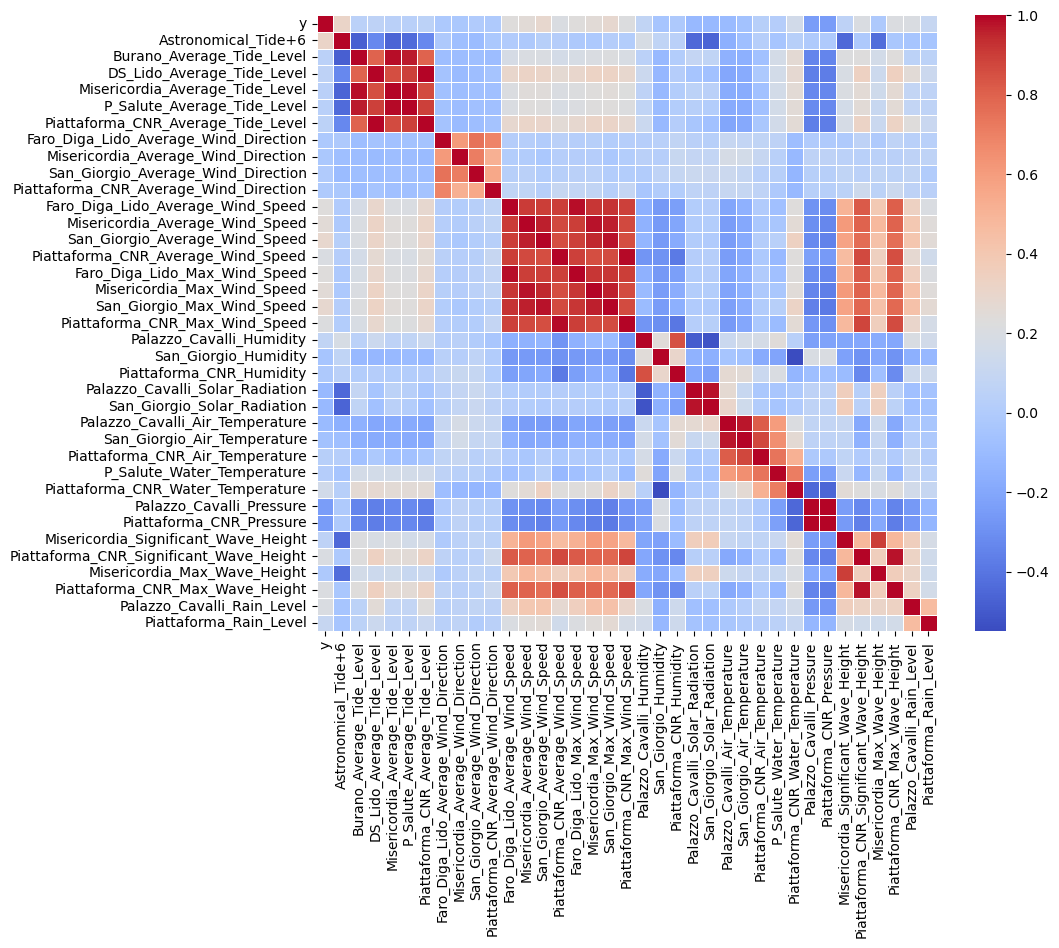

In [579]:
# Calculate the correlation coefficients
corr_matrix = train_df.corr()
plt.figure(figsize=(10,8))
# Plot a heatmap of the correlations
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5, annot=False)

In [373]:
train_df['Average_Tide_Level'] = train_df.iloc[:, 2:7].mean(axis=1)
train_df['Average_Wind_Speed'] = train_df.iloc[:, 11:19].mean(axis=1)
train_df['Average_Solar_Radiation'] = train_df.iloc[:, 22:24].mean(axis=1)
train_df['First_2_Air_Temperature'] = train_df.iloc[:, 24:26].mean(axis=1)
train_df['Average_Pressure'] = train_df.iloc[:, 29:31].mean(axis=1)

test_df['Average_Tide_Level'] = test_df.iloc[:, 1:6].mean(axis=1)
test_df['Average_Wind_Speed'] = test_df.iloc[:, 10:18].mean(axis=1)
test_df['Average_Solar_Radiation'] = test_df.iloc[:, 21:23].mean(axis=1)
test_df['First_2_Air_Temperature'] = test_df.iloc[:, 23:25].mean(axis=1)
test_df['Average_Pressure'] = test_df.iloc[:, 28:30].mean(axis=1)

Drop the variables

In [374]:
train_df.drop(train_df.columns[[2,3,4,5,6,11,12,13,14,15,16,17,18,22,23,24,25,29,30]], axis=1, inplace=True)
test_df.drop(test_df.columns[[1,2,3,4,5,10,11,12,13,14,15,16,17,21,22,23,24,28,29]], axis=1, inplace=True)

In [375]:
test_df

,Astronomical_Tide+6,Faro_Diga_Lido_Average_Wind_Direction,Misericordia_Average_Wind_Direction,San_Giorgio_Average_Wind_Direction,Piattaforma_CNR_Average_Wind_Direction,Palazzo_Cavalli_Humidity,San_Giorgio_Humidity,Piattaforma_CNR_Humidity,Piattaforma_CNR_Air_Temperature,P_Salute_Water_Temperature,...,Piattaforma_CNR_Significant_Wave_Height,Misericordia_Max_Wave_Height,Piattaforma_CNR_Max_Wave_Height,Palazzo_Cavalli_Rain_Level,Piattaforma_Rain_Level,Average_Tide_Level,Average_Wind_Speed,Average_Solar_Radiation,First_2_Air_Temperature,Average_Pressure
0,0.567500,37.001169,30.999543,25.833397,38.001068,70.583333,69.500000,61.750000,7.033333,8.441667,...,1.5475,0.32,2.49,0.0,0.0,0.228500,7.804167,0.000000,5.383333,1008.670833
1,0.109167,281.001528,278.503661,279.804102,279.667213,77.083333,78.000000,69.916667,11.825000,14.108333,...,0.3725,0.42,0.76,0.0,0.0,0.749833,7.227083,0.000000,9.804167,1003.966667
2,0.251667,296.339988,22.186198,198.226958,277.000459,62.583333,70.083333,80.333333,7.608333,9.583333,...,0.2025,0.34,0.47,0.0,0.0,0.152000,2.558333,345.500000,9.825000,1023.141667
3,0.720833,58.333939,48.830619,45.498857,51.334466,88.666667,87.166667,84.166667,6.816667,8.975000,...,0.4400,0.28,0.85,0.0,1.4,0.577000,3.160417,0.000000,7.037500,997.462500
4,-0.210833,45.333042,41.166577,33.499390,48.666654,81.166667,86.166667,82.833333,7.683333,9.108333,...,0.0900,0.41,0.17,0.0,0.0,0.601000,1.252083,61.416667,7.929167,1016.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
861,0.285000,64.333380,24.251478,55.976362,65.334024,98.000000,100.000000,97.083333,6.975000,9.558333,...,1.3250,0.36,2.32,0.0,0.6,0.769667,2.856250,11.958333,6.666667,1002.058333
862,0.788333,50.500102,36.500076,36.165858,47.999949,86.000000,87.583333,85.583333,7.700000,8.675000,...,0.1150,0.21,0.22,0.0,0.0,0.404333,1.702083,0.000000,7.529167,1014.595833
863,0.720833,35.698466,6.538397,26.000000,57.833363,77.083333,78.666667,79.583333,10.408333,14.291667,...,0.5575,0.17,0.98,0.0,0.0,0.457000,4.375000,0.000000,8.495833,1009.604167
864,0.117500,314.978280,291.128295,301.563171,320.149195,91.250000,95.750000,89.750000,9.566667,11.150000,...,0.3000,0.34,0.56,0.0,0.0,0.547667,4.356250,0.208333,9.245833,1022.054167


In [413]:
train_df.iloc[:,24:].corr()

,Palazzo_Cavalli_Air_Temperature,San_Giorgio_Air_Temperature,Piattaforma_CNR_Air_Temperature,P_Salute_Water_Temperature,Piattaforma_CNR_Water_Temperature,Palazzo_Cavalli_Pressure,Piattaforma_CNR_Pressure,Misericordia_Significant_Wave_Height,Piattaforma_CNR_Significant_Wave_Height,Misericordia_Max_Wave_Height,Piattaforma_CNR_Max_Wave_Height,Palazzo_Cavalli_Rain_Level,Piattaforma_Rain_Level
Palazzo_Cavalli_Air_Temperature,1.000000,0.964475,0.813908,0.602848,0.212339,0.073842,0.084033,0.100992,-0.189182,0.130518,-0.191541,-0.011601,-0.038971
San_Giorgio_Air_Temperature,0.964475,1.000000,0.870198,0.633355,0.259872,0.056318,0.064632,0.077014,-0.141894,0.100997,-0.148639,0.022925,-0.016390
Piattaforma_CNR_Air_Temperature,0.813908,0.870198,1.000000,0.743411,0.515032,-0.015227,-0.014028,0.069208,-0.000799,0.078628,-0.004179,0.094227,0.017343
P_Salute_Water_Temperature,0.602848,0.633355,0.743411,1.000000,0.710060,-0.239392,-0.234641,0.110416,-0.123391,0.107451,-0.115647,0.087610,0.044084
Piattaforma_CNR_Water_Temperature,0.212339,0.259872,0.515032,0.710060,1.000000,-0.447445,-0.453422,0.249502,0.226668,0.201753,0.233762,0.155153,0.103781
Palazzo_Cavalli_Pressure,0.073842,0.056318,-0.015227,-0.239392,-0.447445,1.000000,0.999433,-0.242838,-0.331914,-0.180853,-0.344307,-0.262670,-0.124913
Piattaforma_CNR_Pressure,0.084033,0.064632,-0.014028,-0.234641,-0.453422,0.999433,1.000000,-0.258764,-0.357627,-0.192837,-0.369449,-0.271220,-0.128994
Misericordia_Significant_Wave_Height,0.100992,0.077014,0.069208,0.110416,0.249502,-0.242838,-0.258764,1.000000,0.481544,0.900930,0.484088,0.357079,0.179826
Piattaforma_CNR_Significant_Wave_Height,-0.189182,-0.141894,-0.000799,-0.123391,0.226668,-0.331914,-0.357627,0.481544,1.000000,0.357218,0.979457,0.323603,0.146431
Misericordia_Max_Wave_Height,0.130518,0.100997,0.078628,0.107451,0.201753,-0.180853,-0.192837,0.900930,0.357218,1.000000,0.360700,0.312384,0.143557


In [520]:
# Drop the y variable from the train set
X_train = train_df.drop('y', axis=1)
y_train = train_df['y']


In [43]:
# Save clean data
#train_df.to_csv('train_clean.csv', index=False)

# Random Forest

In [377]:
X_train = train_df.drop('y', axis=1)
y_train = train_df['y']

In [358]:
# Create a Random Forest model
rf_model = RandomForestClassifier(n_estimators=500, max_depth=20) #, random_state=42
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=500)

In [359]:
y_pred = rf_model.predict(test_df)

In [360]:
np.savetxt("y_predfor3.txt", y_pred, fmt="%d")

# Gradient Boosting

In [203]:
class loguniform_int:
    """Integer valued version of the log-uniform distribution"""
    def __init__(self, a, b):
        self._distribution = loguniform(a, b)

    def rvs(self, *args, **kwargs):
        """Random variable sample"""
        return self._distribution.rvs(*args, **kwargs).astype(int)

In [222]:
param_distributions = {
    'n_estimators': loguniform_int(50, 200),
    'learning_rate': loguniform(0.1, 0.5),
    'max_depth': loguniform_int(1, 4)
}

In [223]:
# Use cross validation randomized search to find find optimal hyperparameters
model_random_search = RandomizedSearchCV(gb_model, param_distributions = param_distributions, n_iter=50, cv=5)

In [224]:
model_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingClassifier(learning_rate=0.34068,
                                                        max_depth=5,
                                                        n_estimators=176,
                                                        random_state=16),
                   n_iter=50,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000018580EA1370>,
                                        'max_depth': <__main__.loguniform_int object at 0x0000018580E7DDC0>,
                                        'n_estimators': <__main__.loguniform_int object at 0x0000018580E7DD00>})

In [227]:
print("The best parameters are:")
pprint(model_random_search.best_params_)

The best parameters are:
{'learning_rate': 0.29963050108860395, 'max_depth': 2, 'n_estimators': 139}


In [231]:
# get the parameter stats
column_results = [f"param_{name}" for name in param_distributions.keys()] + ["mean_test_score", "std_test_score", "rank_test_score"]

cv_results = pd.DataFrame(model_random_search.cv_results_)
cv_results = cv_results[column_results].sort_values("mean_test_score", ascending=False)

def shorten_param(param_name):
    if "__" in param_name:
        return param_name.rsplit("__", 1)[1]
    return param_name

cv_results = cv_results.rename(shorten_param, axis=1)
cv_results.head(10)

,param_n_estimators,param_learning_rate,param_max_depth,mean_test_score,std_test_score,rank_test_score
29,139,0.299631,2,0.952,0.008124,1
22,57,0.118497,3,0.951,0.010198,2
41,163,0.116097,2,0.951,0.007348,2
17,101,0.159357,2,0.951,0.008000,2
3,144,0.176523,3,0.951,0.012806,5
32,168,0.136884,3,0.951,0.011136,5
13,110,0.317709,1,0.950,0.011402,7
43,169,0.169338,1,0.950,0.008944,7
27,85,0.362913,3,0.950,0.009487,7
0,54,0.217814,3,0.950,0.009487,7


In [361]:
# Create a Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators= 139, max_depth=2, learning_rate= 0.299631, random_state=16)
gb_model.fit(X_train, y_train)

# Predict on the test set and calculate accuracy
y_pred = gb_model.predict(test_df)


In [362]:
np.savetxt("y_predgboo5.txt", y_pred, fmt="%d")

# Ada Boosting

In [557]:
param_distributions = {
    'n_estimators': loguniform_int(80, 180),
    'learning_rate': loguniform(0.95, 1.35),
    'base_estimator__max_depth': loguniform_int(2, 5)
}

In [558]:
def mine_scorer(y_true, y_pred):
    conf_matrix = confusion_matrix(y_pred, y_true)
    score = 5 * conf_matrix[0, 1] + 1 * conf_matrix[1, 0]

    return -score  # return negative penalty for minimization

adaboost_model = AdaBoostClassifier()
scorer = make_scorer(mine_scorer)
model_random_search = RandomizedSearchCV(adaboost_model, param_distributions=param_distributions, n_iter=100, cv=5, scoring=scorer)


In [559]:
model_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3),
                                                learning_rate=1.137677,
                                                n_estimators=116),
                   n_iter=100,
                   param_distributions={'base_estimator__max_depth': <__main__.loguniform_int object at 0x000001858A0FF8B0>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001858A1C3EE0>,
                                        'n_estimators': <__main__.loguniform_int object at 0x000001858A1C3D90>},
                   scoring=make_scorer(mine_scorer))

In [560]:
from pprint import pprint

print("The best parameters are:")
pprint(model_random_search.best_params_)

The best parameters are:
{'base_estimator__max_depth': 2,
 'learning_rate': 1.3364595531675625,
 'n_estimators': 87}


In [561]:
# get the parameter names
column_results = [f"param_{name}" for name in param_distributions.keys()] + ["mean_test_score", "std_test_score", "rank_test_score"]

cv_results = pd.DataFrame(model_random_search.cv_results_)
cv_results = cv_results[column_results].sort_values("mean_test_score", ascending=False)

def shorten_param(param_name):
    if "__" in param_name:
        return param_name.rsplit("__", 1)[1]
    return param_name

cv_results = cv_results.rename(shorten_param, axis=1)
cv_results.head(10)

,param_n_estimators,param_learning_rate,max_depth,mean_test_score,std_test_score,rank_test_score
97,87,1.33646,2,-37.8,8.885944,1
4,152,1.238516,4,-39.4,8.014986,2
74,162,1.346032,2,-40.6,5.607138,3
35,161,1.088605,2,-41.2,5.912698,4
13,85,1.041026,3,-42.4,8.357033,5
49,117,1.145703,2,-42.6,7.227724,6
20,127,1.213986,3,-42.6,4.127953,6
18,135,1.286113,4,-43.0,3.346640,8
11,119,0.976527,3,-43.0,6.131884,8
44,90,1.063528,3,-43.0,6.099180,8


In [540]:
cv_results["param_n_estimators"] = cv_results["param_n_estimators"].astype(np.int64)
cv_results["param_learning_rate"] = cv_results["param_learning_rate"].astype(np.int64)
cv_results["max_depth"] = cv_results["max_depth"].astype(np.int64)


In [568]:
# Create an Adaboost model
adaboost_model = AdaBoostClassifier(n_estimators= 87, learning_rate= 1.33646, base_estimator= DecisionTreeClassifier(max_depth=2), algorithm = 'SAMME.R')
adaboost_model.fit(X_train, y_train)

y_pred = adaboost_model.predict(test_df)

In [513]:
importances = adaboost_model.feature_importances_

importances_df = pd.DataFrame({'feature':X_train.columns,'importance':np.round(importances,3)})
importances_df = importances_df.sort_values('importance',ascending=False).set_index('feature')
importances_df.head(6)

,importance
feature,
Astronomical_Tide+6,0.123
Misericordia_Average_Wind_Direction,0.064
Faro_Diga_Lido_Average_Wind_Direction,0.046
Misericordia_Significant_Wave_Height,0.045
Piattaforma_CNR_Water_Temperature,0.045
San_Giorgio_Humidity,0.041


In [569]:
np.savetxt("y_predAboo8.txt", y_pred, fmt="%d")